In [1]:
# DAY 7 : State Cluster Analysis
# GOAL  : Leting the model discover natural studentgroups on its own — no labels given
#         This is UNSUPERVISED LEARNING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('../data/cleaned/student_lifestyle_engineered.csv')

In [4]:
df.shape

(1000, 26)

In [5]:
#Select state variables only for clustering
cluster_features = ['stress_level',
                    'anxiety_score',
                    'sleep_hours',
                    'mood_rating',
                    'state_score',
                    'sleep_debt',
                    'stress_sleep_ratio']
X_cluster = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(f"Shape : {X_scaled.shape}")

Shape : (1000, 7)


C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

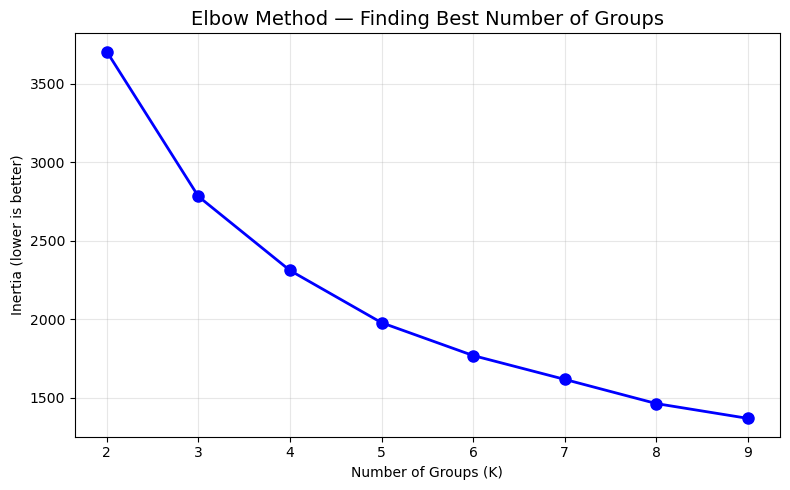

In [6]:
#: Elbow method — finds the best number of groups
import os
os.environ['OMP_NUM_THREADS'] = '4'

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Finding Best Number of Groups', fontsize=14)
plt.xlabel('Number of Groups (K)')
plt.ylabel('Inertia (lower is better)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/10_elbow_method.png')
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Students grouped into 3 clusters!")
print(f"\nGroup sizes:")
print(df['cluster'].value_counts())


Students grouped into 3 clusters!

Group sizes:
cluster
0    478
1    286
2    236
Name: count, dtype: int64


C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [8]:
profile = df.groupby('cluster')[cluster_features].mean().round(2)
print("=" * 55)
print("AVERAGE PROFILE OF EACH STUDENT GROUP")
print("=" * 55)
print(profile)

AVERAGE PROFILE OF EACH STUDENT GROUP
         stress_level  anxiety_score  sleep_hours  mood_rating  state_score  \
cluster                                                                       
0                5.62           5.70         6.43         5.41         5.30   
1                7.52           7.65         5.23         3.59         7.19   
2                3.76           3.54         7.38         7.06         3.41   

         sleep_debt  stress_sleep_ratio  
cluster                                  
0              1.57                0.88  
1              2.77                1.48  
2              0.62                0.51  


In [9]:
cluster_names = {
    0: 'Struggling',
    1: 'Burned Out',
    2: 'Thriving'
}

df['student_type'] = df['cluster'].map(cluster_names)

print("Groups named!")
print(df['student_type'].value_counts())

Groups named!
student_type
Struggling    478
Burned Out    286
Thriving      236
Name: count, dtype: int64


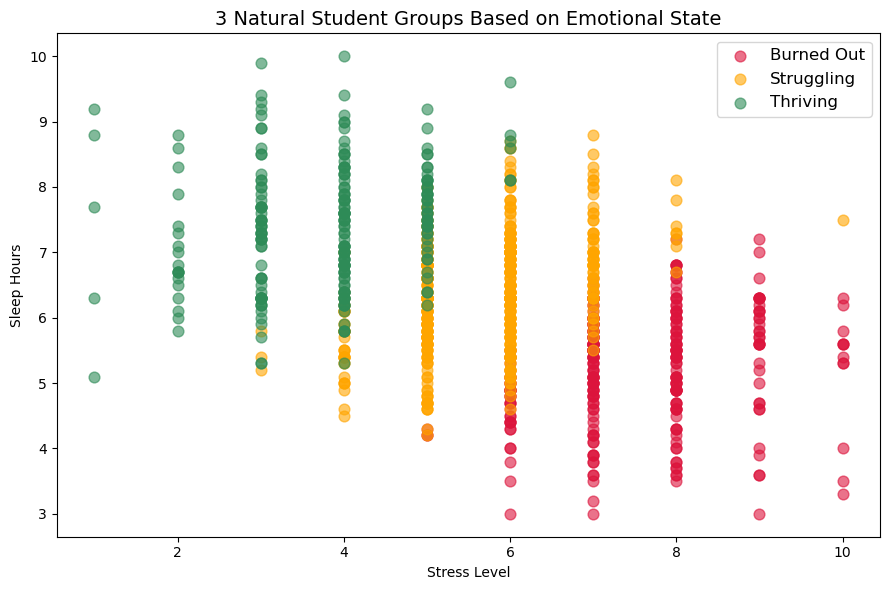

In [10]:
#Show all 3 groups on one chart

plt.figure(figsize=(9,6))
colors = {'Burned Out': 'crimson', 
          'Struggling': 'orange', 
          'Thriving': 'seagreen'}

for group, color in colors.items():
    mask = df['student_type'] == group
    plt.scatter(df[mask]['stress_level'],
                df[mask]['sleep_hours'],
                c=color, label=group,
                alpha=0.6, s=60)

plt.title('3 Natural Student Groups Based on Emotional State',
          fontsize=14)
plt.xlabel('Stress Level')
plt.ylabel('Sleep Hours')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/11_student_clusters.png')
plt.show()

In [11]:
# Save dataset with cluster columns included
df.to_csv('../data/cleaned/student_lifestyle_final.csv', index=False)
print("final dataset saved with cluster labels!")
print(f"Total columns : {df.shape[1]}")
print(f"\nColumns added:")
print("  - cluster")
print("   - student_type")

final dataset saved with cluster labels!
Total columns : 28

Columns added:
  - cluster
   - student_type
